In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import yfinance as yf
import seaborn as sns

np.random.seed(101)
az.style.use('arviz-darkgrid')
sns.set_style('darkgrid')

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
start = datetime(2022, 11, 15)
end = datetime(2022, 12, 31)
market = yf.Ticker('SPY').history(start=start, end=end)
stock = yf.Ticker('AAPL').history(start=start, end=end)
riskfree_rate = yf.Ticker('^TNX').history(start=start, end=end)  # 10 year US treasury note


daily_returns = pd.DataFrame(
    index=stock.index,
    data={
        'market': (market['Close'].pct_change(1) * 100).values,
        'stock': (stock['Close'].pct_change(1) * 100).values,
        'riskfree': ((1 + riskfree_rate['Close']) ** (1/360) - 1).values
    }
)

# market.index.difference(riskfree_rate.index)
daily_returns = daily_returns.ffill()
daily_returns = daily_returns.dropna()
daily_returns.isnull().sum()
daily_returns.head()

,market,stock,riskfree
Date,,,
2022-11-16 00:00:00-05:00,-0.762908,-0.833111,0.004303
2022-11-17 00:00:00-05:00,-0.305970,1.297139,0.004352
2022-11-18 00:00:00-05:00,0.454030,0.378185,0.004377
2022-11-21 00:00:00-05:00,-0.363602,-2.168038,0.004381
2022-11-22 00:00:00-05:00,1.345702,1.466132,0.004342


Text(0.5, 0, 'Excess returns of S&P 500')

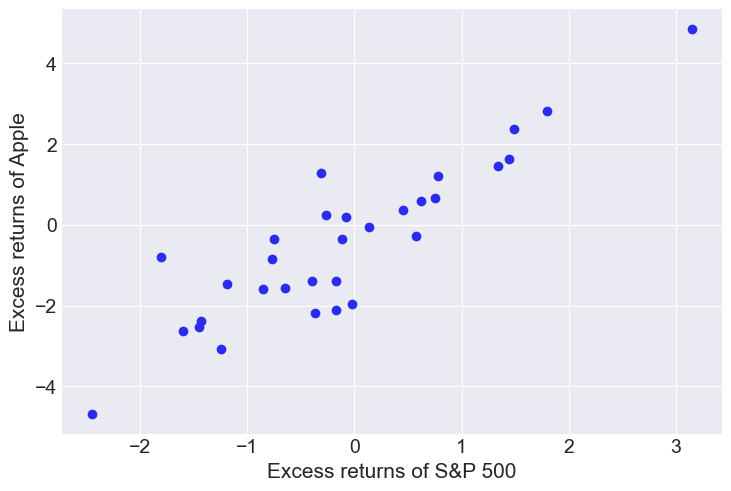

In [3]:
y = daily_returns['stock'] - daily_returns['riskfree']
x = daily_returns['market'] - daily_returns['riskfree']

plt.scatter(x, y)
plt.ylabel('Excess returns of Apple')
plt.xlabel('Excess returns of S&P 500')

Text(0.5, 0, 'Excess returns of Apple')

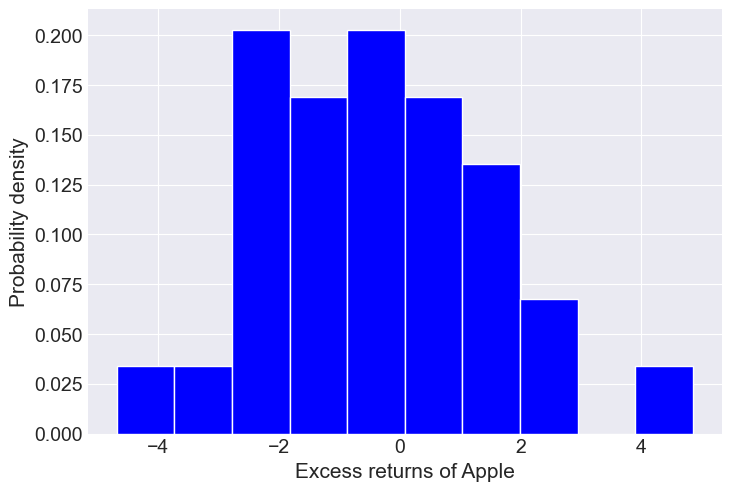

In [4]:
plt.hist(y, density=True, color='blue')
plt.ylabel('Probability density')
plt.xlabel('Excess returns of Apple')

In [5]:
daily_returns.describe()

,market,stock,riskfree
count,31.000000,31.000000,31.000000
mean,-0.110990,-0.444417,0.004282
std,1.192476,1.967496,0.000083
min,-2.446177,-4.685426,0.004129
25%,-0.805442,-1.775150,0.004200
50%,-0.171754,-0.343511,0.004299
75%,0.602687,0.635440,0.004340
max,3.150074,4.859374,0.004417


In [6]:
test_size = 10

x_train = x[:-test_size]
y_train = y[:-test_size]

x_test = x[-test_size:]
y_test = y[-test_size:]

In [7]:
model = pm.Model()

with model:
    # P(a), P(b), P(sigma) are the prior probability distributions of the model's parameters.
    # Define the prior probability distributions of the model's parameters. Use prior domain knowledge.
    alpha = pm.Normal('alpha', mu=0.02, sigma=0.10)
    beta = pm.Normal('beta', mu=1.2, sigma=0.15)
    residual = pm.HalfStudentT('residual', sigma=1, nu=6)

    # Mutatable data containers are used so that we can swap out training data for test data later.
    feature = pm.MutableData('feature', x_train, dims='feature_data')
    target = pm.MutableData('target', y_train, dims='target_data')

    # Expected daily excess returns of Apple are approximately linearly related to daily excess returns of S&P 500
    # The function specifies the linear model and the expected return. It creates a deterministic variable in the trace object.
    target_expected = pm.Deterministic('target_expected', alpha + beta * feature, dims='feature_data')

    # P(D|a, b, sigma) is the likelihood function of the model. 
    # Assign the training data sample to the likelihood function.
    # Daily excess stock price returns are assumed to be T-distributed with nu=6.
    target_likelihood = pm.StudentT(
        'target_likelihood', 
        mu=target_expected, 
        sigma=residual, 
        nu=6, 
        observed=target, 
        dims='target_data'
    )


In [8]:
# Sample from the prior distributions and the likelihood function 
# to generate prior predictive distribution of the model.
# Take 1000 draws from the prior predictive distribution 
# to simulate (1000*21) target values based on our prior assumptions.
inference_data = pm.sample_prior_predictive(
    samples=1000, 
    model=model, 
    return_inferencedata=True, 
    random_seed=101
)

# PyMC/Arviz returns an xarray - a labeled, multidimensional array 
# containing inference data samples structured into groups. Note the 
# dimensions of the prior predictive group to see how we got (1*1000*21) 
# simulated target data of the prior predictive distribution.
inference_data

Sampling: [alpha, beta, residual, target_likelihood]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'residual'}>,
        <Axes: title={'center': 'residual'}>]], dtype=object)

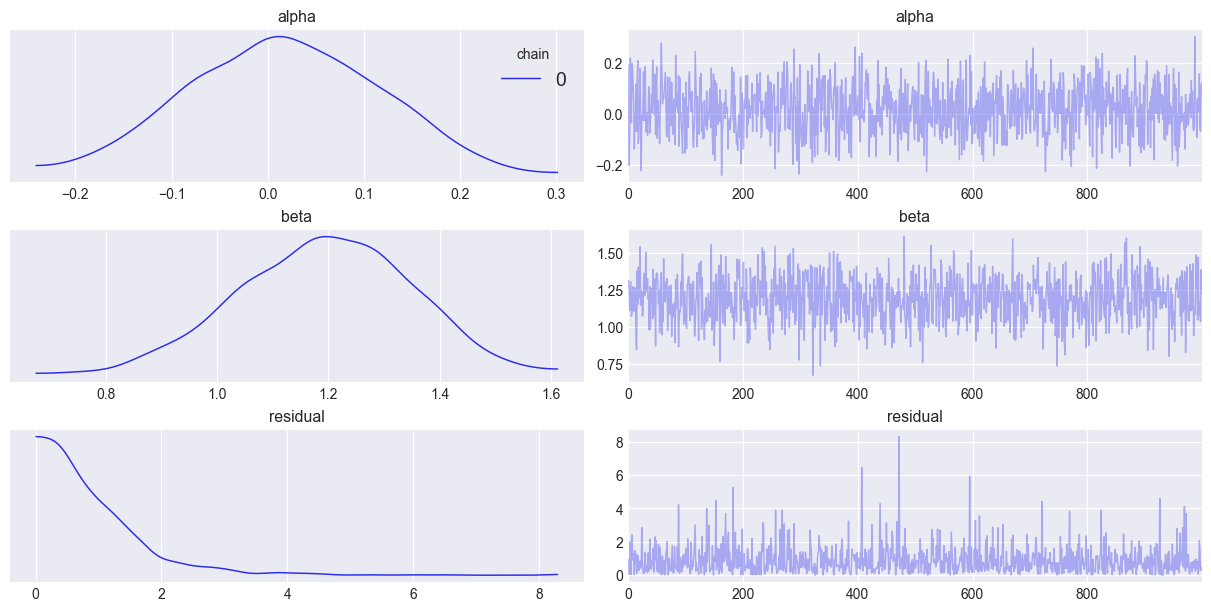

In [9]:
# Subplots on the left show the kernel density estimates (KDE) of 
# the marginal prior probability distributions of model parameters 
# from the 1000 samples drawn. Subplots on the right show the parameter 
# values from a single Markov chain that were sampled sequentially 
# by the NUTS sampler, the default regression sampler.
az.plot_trace(
    inference_data.prior, 
    kind='trace', 
    var_names=['alpha', 'beta', 'residual'], 
    legend=True
)

array([<Axes: title={'center': 'alpha'}>,
       <Axes: title={'center': 'beta'}>,
       <Axes: title={'center': 'residual'}>], dtype=object)

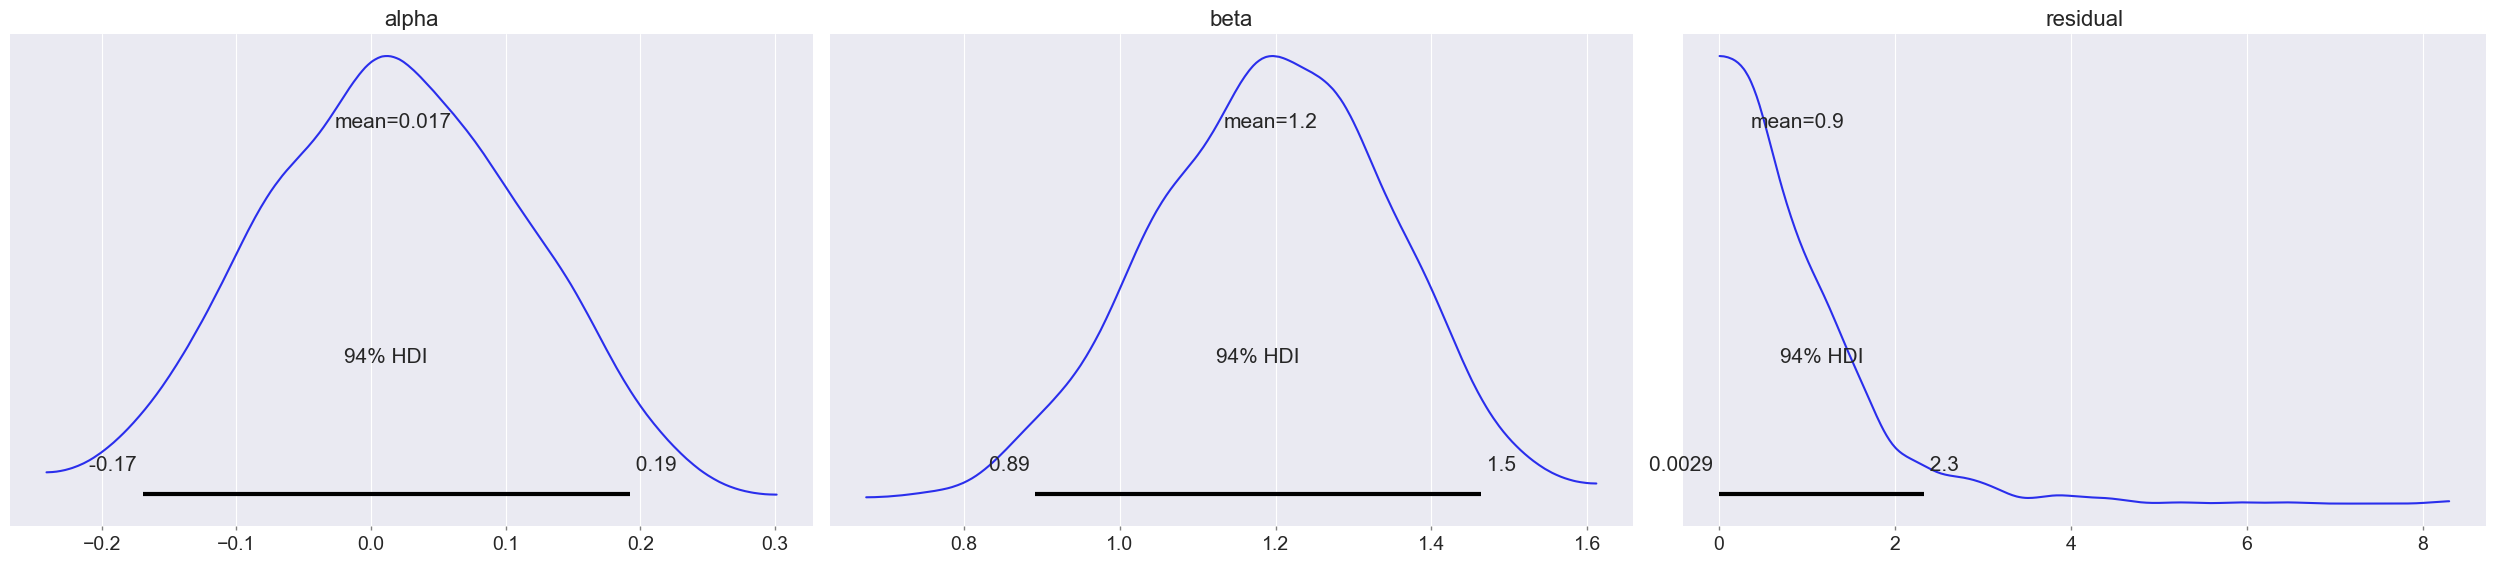

In [10]:
# Plot the marginal prior distributions of each parameter with 94% 
# highest density intervals (HDI).
# Note the residual subplot shows the majority of probability density function
# within 3 percentage points and the rest extending out into a long tail.
# In Arviz, there is no method to plot the prior marginal distributions but we 
# can hack the plot posterior method and use the prior group instead.
az.plot_posterior(
    inference_data.prior, 
    var_names=['alpha', 'beta', 'residual'], 
    round_to=2
)

array([[<Axes: >, None],
       [<Axes: xlabel='alpha', ylabel='beta'>, <Axes: >]], dtype=object)

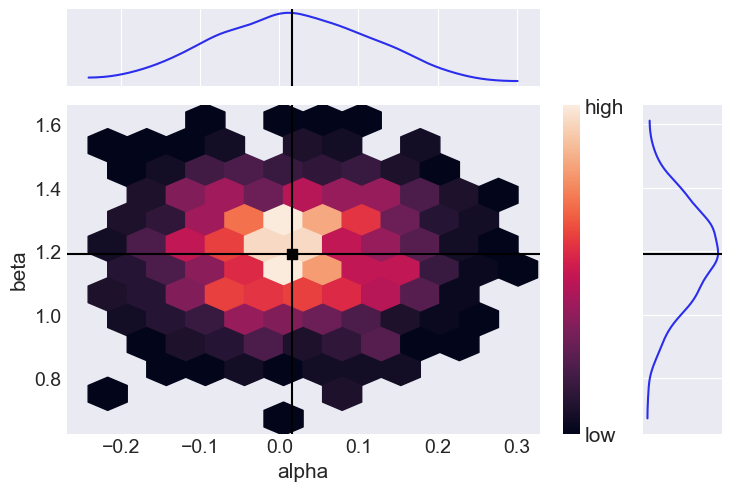

In [11]:
# Plot the joint prior probability distribution of alpha and beta with their 
# respective means and marginal distributions on the side.
# Hexabin plot below shows little or no linear correlation with the high 
# concentration areas in the heat map forming a cloud.
az.plot_pair(
    inference_data.prior, 
    var_names=['alpha', 'beta'], 
    kind='hexbin', 
    marginals=True, 
    point_estimate='mean', 
    colorbar=True
)

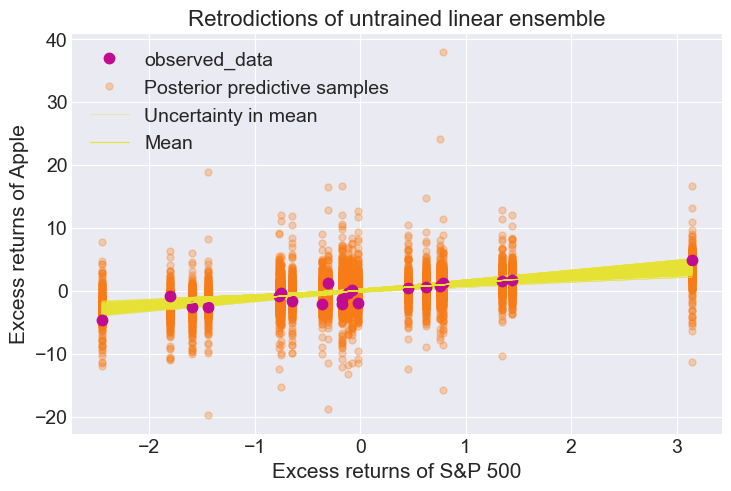

In [12]:
# Plot the retrodictions of prior predictive ensemble.

# Retrieve feature and target training data from the constant_data group.
# Feature is now an xarray instead of a Panda's series, a requirement for ArViz data analysis.
feature_train = inference_data.constant_data['feature']
target_train = inference_data.constant_data['target']

# Generate 1000 linear regression lines based on 1000 draws 
# from one Markov chain of the prior distributions of alpha and beta.
# Prior target values are in 1000 arrays with each array having 21 samples, 
# the same number of samples as our training data set.
prior_target = inference_data.prior["alpha"] + inference_data.prior["beta"] * feature_train

# Prior_predictive is the data generating distribution of the untrained ensemble.
prior_predictive = inference_data.prior_predictive['target_likelihood']

# Create figure of subplots.
fig, ax = plt.subplots()

# Plot epistemic and aleatory uncertainties of untrained ensemble's retrodictions.
az.plot_lm(
    idata=inference_data, 
    x=feature_train, 
    y=target_train, 
    num_samples=1000, 
    y_model = prior_target, 
    y_hat = prior_predictive, 
    axes=ax
)

ax.set_xlabel("Excess returns of S&P 500")
ax.set_ylabel("Excess returns of Apple")
ax.set_title("Retrodictions of untrained linear ensemble")
ax.legend(loc='upper left')

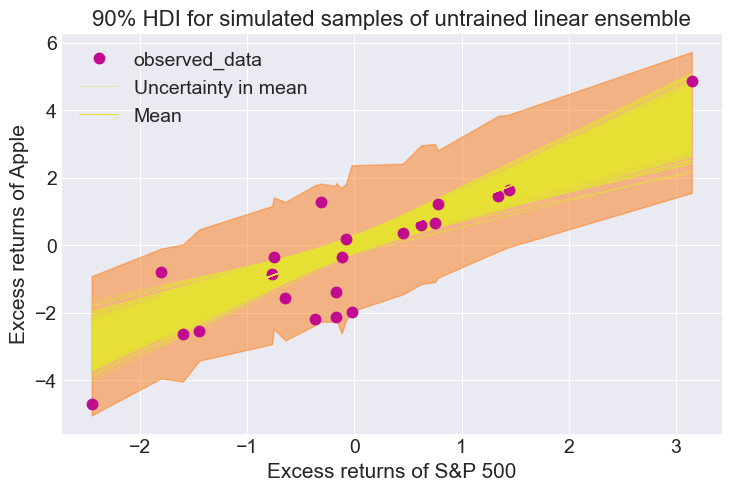

In [13]:
# Plot 90% HDI of untrained ensemble.
# This will show the aleatory (data related) and epistemic 
# (parameter related) uncertainty of model output before it is trained.

# Create figure of subplots.
fig, ax = plt.subplots()

# Plot the ensemble of 1000 regression lines to show the 
# epistemic uncertainty around the mean regression line.
az.plot_lm(
    idata=inference_data, x=feature_train, y=target_train, 
    num_samples=1000, y_model=prior_target, axes=ax
)

# Plot the prior predictive data within the 90% HDI band to 
# show both epistemic and aleatory uncertainties.
az.plot_hdi(feature_train, prior_predictive, hdi_prob=0.90, smooth=False)

# Label figure.
ax.set_xlabel("Excess returns of S&P 500")
ax.set_ylabel("Excess returns of Apple")
ax.set_title("90% HDI for simulated samples of untrained linear ensemble")
ax.legend()

Text(0.5, 1.0, 'Prior predictive check of untrained linear ensemble')

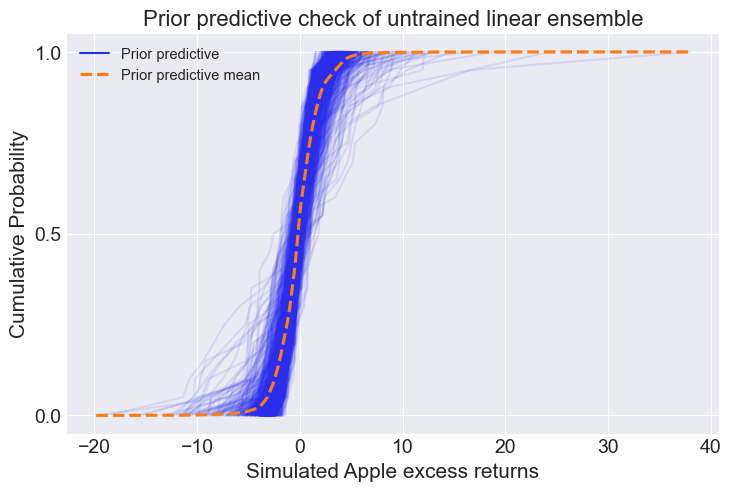

In [14]:
# Conduct a prior predictive check of the untrained linear ensemble.
fig, ax = plt.subplots()
az.plot_ppc(
    inference_data, 
    group='prior', 
    kind='cumulative', 
    num_pp_samples=1000, 
    alpha=0.1, 
    ax=ax
)
ax.set_xlabel("Simulated Apple excess returns")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Prior predictive check of untrained linear ensemble")

In [15]:
# Evaluate untrained ensemble's retrodictions by comparing simulated 
# data with training data.

# Extract target values of our training data.
target_actual = target_train.values

# Sample the prior predictive distribution to simulate 
# expected target training values.
target_predicted = inference_data.prior_predictive.stack(sample=("chain", "draw"))['target_likelihood'].values.T

# Use the probabilistic R-squared metric.
prior_score = az.r2_score(target_actual, target_predicted)
prior_score.round(2)

r2        0.61
r2_std    0.10
dtype: float64

In [16]:
# Draw 1000 samples from two Markov chains resulting in 2000 values of each
# parameter to analyze the joint posterior distribution.
# Check for any divergences in the progress bar. We want 0 divergences for a 
# reliable sampling of the posterior distribution.
inference_data.extend(pm.sample(draws=1000, chains=2, model=model, random_seed=101))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [alpha, beta, residual]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


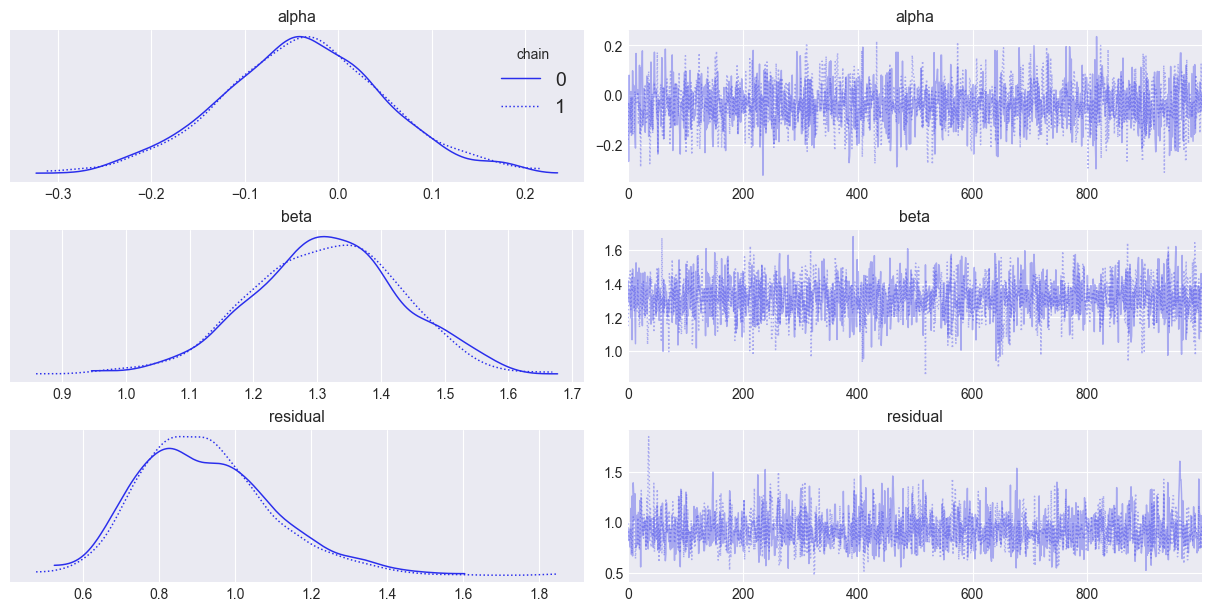

In [17]:
# Subplots on the left show the kernel density estimates (KDE)
# of the marginal posterior probability distributions of each parameter.
# Subplots on the right show the parameter values 
# that were sampled sequentially in two chains by the NUTS sampler
with model:
    az.plot_trace(
        inference_data.posterior, 
        kind='trace',
        var_names = ['alpha', 'beta', 'residual'], 
        legend=True
    )

array([[<Axes: >, None],
       [<Axes: xlabel='alpha', ylabel='beta'>, <Axes: >]], dtype=object)

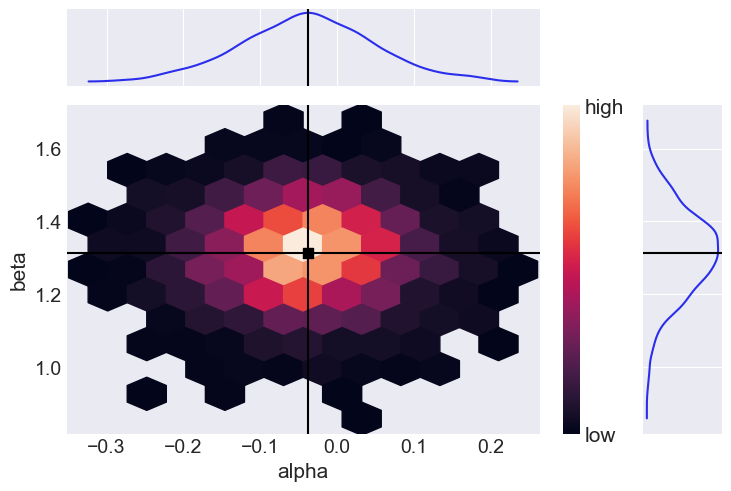

In [18]:
# Plot the joint posterior probability distribution of alpha and beta 
# with their respective means and marginal distributions on the side.
# Hexabin plot below shows little or no linear correlation with the 
# high concentration areas in the heat map forming a cloud.
az.plot_pair(
    inference_data.posterior, 
    var_names=['alpha', 'beta'], 
    kind='hexbin',
    marginals=True, 
    point_estimate='mean', 
    colorbar=True
)

In [19]:
# Examine sample statistics of each parameter's posterior marginal distribution, 
# including it's 94% highest density interval (HDI).
display(
    az.summary(
        inference_data, 
        kind='stats', 
        var_names = ['alpha', 'beta', 'residual'], 
        round_to=2, 
        hdi_prob=0.94
    )
)

,mean,sd,hdi_3%,hdi_97%
alpha,-0.04,0.09,-0.22,0.13
beta,1.31,0.12,1.09,1.53
residual,0.92,0.17,0.63,1.26


array([<Axes: title={'center': 'alpha'}>,
       <Axes: title={'center': 'beta'}>,
       <Axes: title={'center': 'residual'}>], dtype=object)

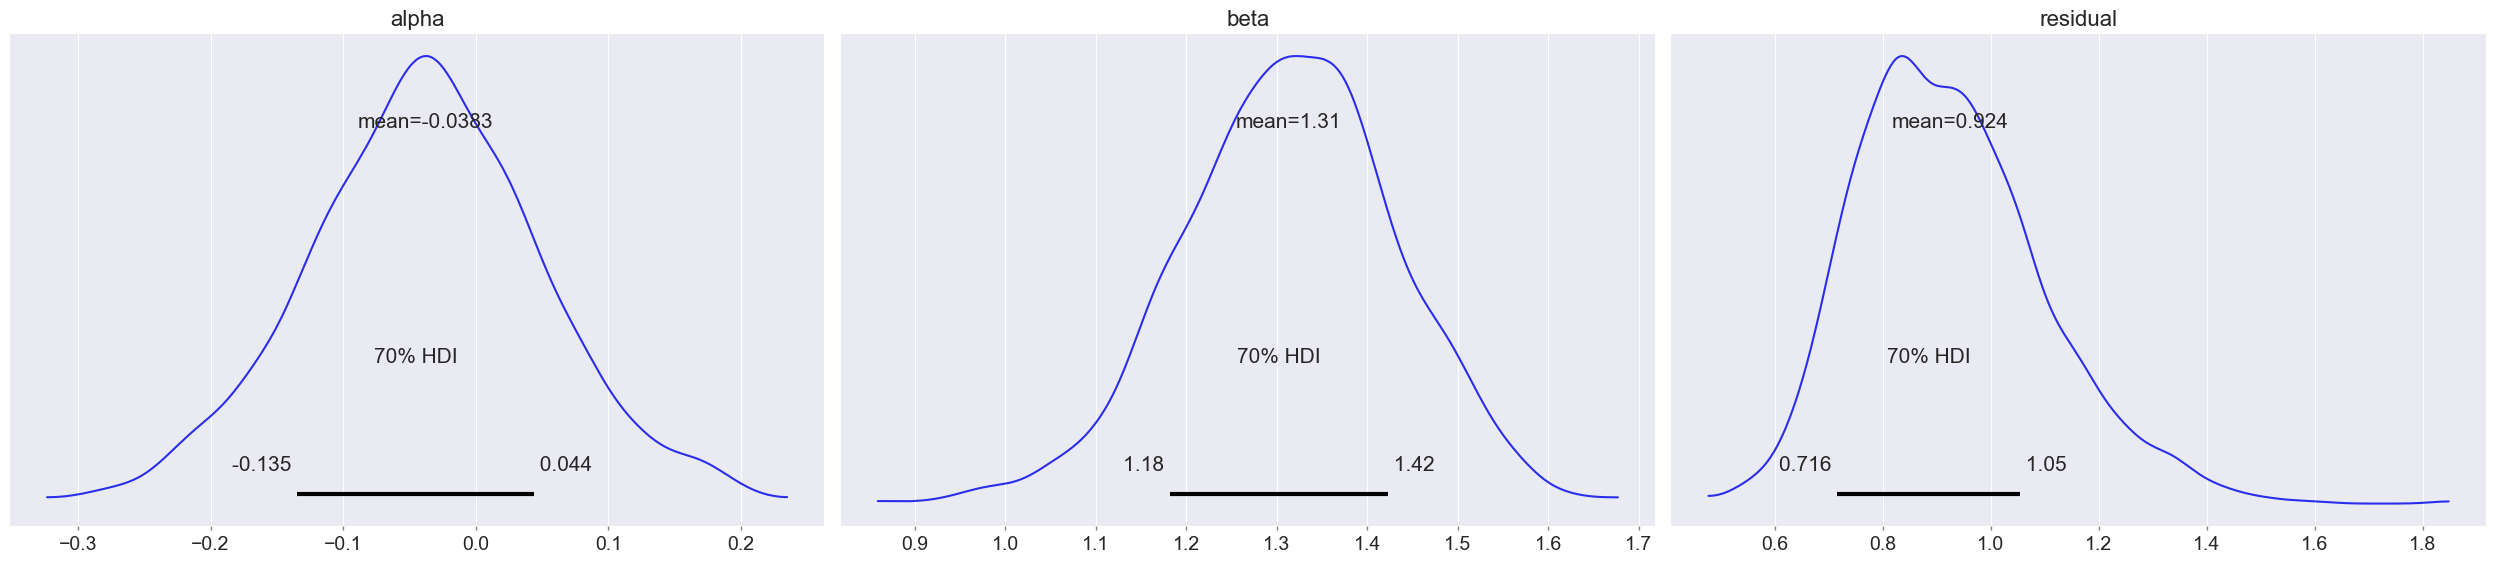

In [20]:
# Plot the marginal posterior distribution of each parameter displaying 
# the above statistics but now within a 70% HDI
az.plot_posterior(
    inference_data, 
    var_names = ['alpha', 'beta', 'residual'], 
    hdi_prob=0.70, 
    round_to=3
)

<Axes: title={'center': 'beta'}>

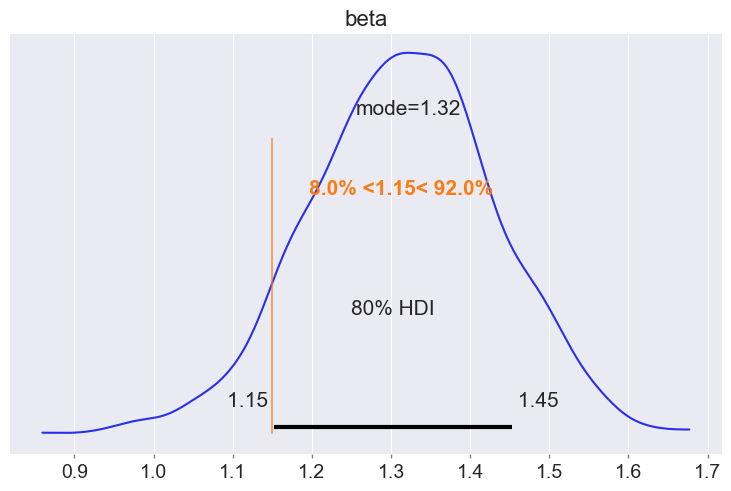

In [21]:
# Evaluate a point estimate for a single parameter using its 
# posterior distribution.
az.plot_posterior(
    inference_data, 
    'beta', 
    ref_val=1.15, 
    hdi_prob=0.80, 
    point_estimate='mode', 
    round_to=3
)

In [22]:
# Draw 1000 samples each from two Markov chains of the 
# posterior predictive distribution.
with model:
    pm.sample_posterior_predictive(
        inference_data, 
        extend_inferencedata=True, 
        random_seed=101
    )

Sampling: [target_likelihood]


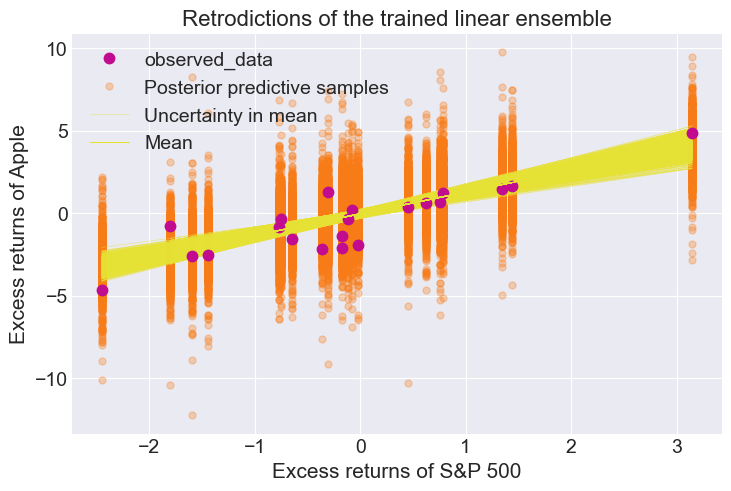

In [23]:
# Generate 2000 linear regression lines based on 1000 draws each from 
# two chains of the posterior distributions of alpha and beta.
# Posterior target values are in 2000 arrays, each with 21 samples, 
# the same number of samples as our training data set.
posterior = inference_data.posterior
posterior_target = posterior["alpha"] + posterior["beta"] * feature_train

# Posterior_predictive is the data generating distribution of the 
# trained ensemble.
posterior_predictive = inference_data.posterior_predictive['target_likelihood']

# Create figure of subplots.
fig, ax = plt.subplots()

# Plot epistemic and aleatory uncertainties of trained 
# ensemble's retrodictions.
az.plot_lm(
    idata=inference_data, x=feature_train, y=target_train, num_samples=2000,
    y_model = posterior_target, y_hat=posterior_predictive, axes=ax
)
# Label the figure.
ax.set_xlabel("Excess returns of S&P 500")
ax.set_ylabel("Excess returns of Apple")
ax.set_title("Retrodictions of the trained linear ensemble")
ax.legend(loc='upper left')

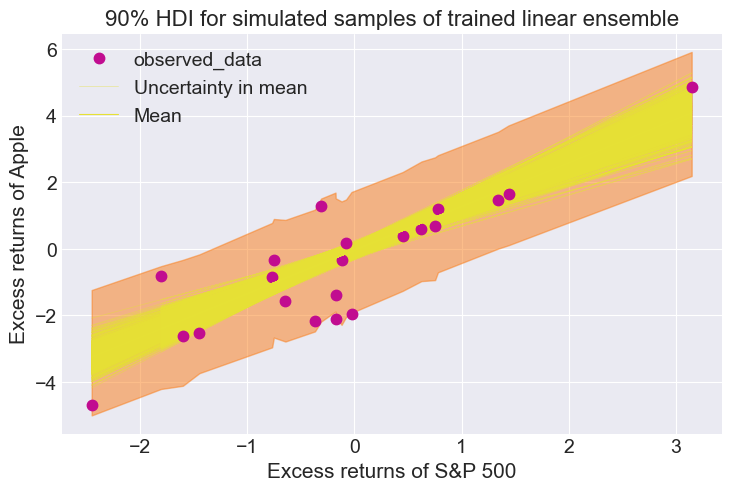

In [24]:
# Plot 90% HDI of trained ensemble.
# This will show the aleatory (data related) and epistemic 
# (parameter related) uncertainty of model output after it is trained.

# Create figure of subplots.
fig, ax = plt.subplots()

# Plot the ensemble of 2000 regression lines to show the epistemic 
# uncertainty around the mean regression line.
az.plot_lm(
    idata=inference_data, x=feature_train, y=target_train, 
    num_samples=1000, y_model = posterior_target, axes=ax
)

# Plot the posterior predictive data within the 90% HDI band to show both 
# epistemic and aleatory uncertainties.
az.plot_hdi(feature_train, posterior_predictive, hdi_prob=0.90, smooth=False)

# Label the figure
ax.set_xlabel("Excess returns of S&P 500")
ax.set_ylabel("Excess returns of Apple")
ax.set_title("90% HDI for simulated samples of trained linear ensemble");

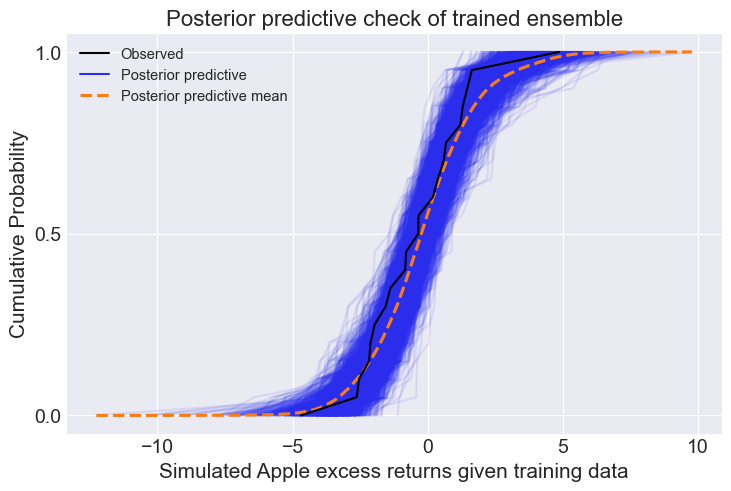

In [ ]:
# Conduct a posterior predictive check of the trained linear ensemble.

# Create a figure of subplots.
fig, ax = plt.subplots()

# Plot the posterior predictive check.
az.plot_ppc(inference_data, group='posterior', kind='cumulative', 
num_pp_samples=2000, alpha=0.1, ax=ax)

# Label the figure.
ax.set_xlabel("Simulated Apple excess returns given training data")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Posterior predictive check of trained ensemble")

In [26]:
# Evaluate trained ensemble's retrodictions by comparing
# simulated data with training data.

# Get target values of our training data
target_actual = target_train.values

# Sample the posterior predictive distribution 
# conditioned on training data.
target_predicted = inference_data.posterior_predictive.stack(sample=("chain", "draw"))['target_likelihood'].values.T

# Compute probabilistic R-squared performance metric.
training_score = az.r2_score(target_actual, target_predicted)
training_score.round(2)


r2        0.63
r2_std    0.09
dtype: float64

In [27]:
# Now we use our trained model to make predictions based on test data. 
# This is the reason we created mutable data containers earlier.
with model:
    #Swap feature and target training data for their respective test data.
    pm.set_data({'feature': x_test, 'target': y_test})
    #Create two new inference groups, predictions and predictions_constant_data 
    #for making predictions based on features in the test data.
    pm.sample_posterior_predictive(
        inference_data, return_inferencedata=True, 
        predictions=True, extend_inferencedata=True, random_seed=101
    )

Sampling: [target_likelihood]


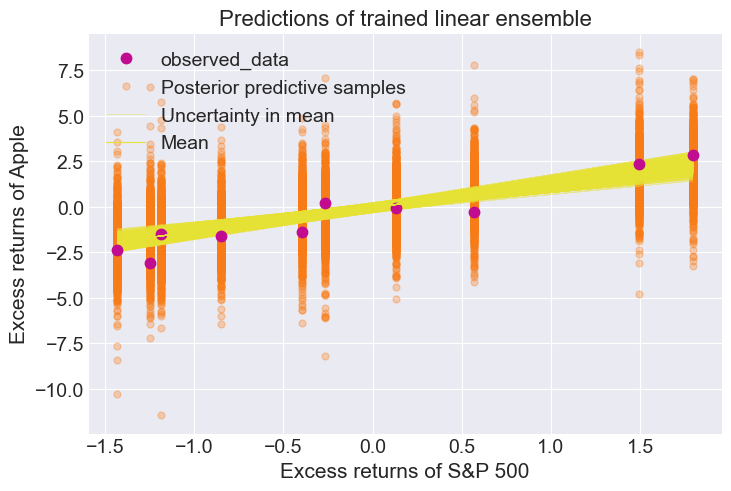

In [28]:
# Get feature and target test data.
feature_test = inference_data.predictions_constant_data['feature']
target_test = inference_data.predictions_constant_data['target']

# Prediction target values are in 2000 arrays, each with 10 samples,
# the same number of samples as our test data set. Predict target values 
# based on posterior values of regression parameters and feature test data.
prediction_target = posterior["alpha"] + posterior["beta"] * feature_test

# Predictions is the data generating posterior predictive distribution 
# of the trained ensemble based on test data.
simulate_predictions = inference_data.predictions['target_likelihood']
# Create figure of subplots.
fig, ax = plt.subplots()

# Plot the 2000 regression lines showing the epistemic and 
# aleatory uncertainties of out-of-sample predictions.
az.plot_lm(idata=inference_data, x=feature_test, y=target_test, num_samples=2000, 
y_model = prediction_target, y_hat=simulate_predictions, axes=ax)

# Label figure
ax.set_xlabel("Excess returns of S&P 500")
ax.set_ylabel("Excess returns of Apple")
ax.set_title("Predictions of trained linear ensemble")
ax.legend(loc='upper left')

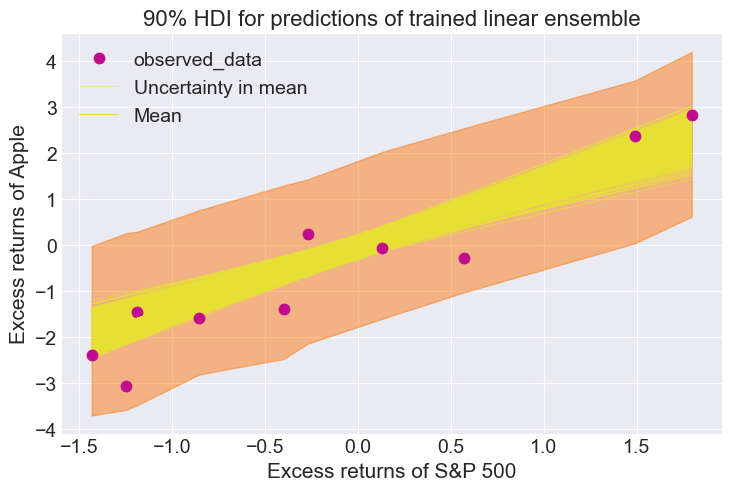

In [29]:
# Plot 90% HDI of trained ensemble. This will show the aleatory 
# (data related) and epistemic (parameter related) uncertainty 
# of trained model's predictions based on test data.

# Create figure of subplots.
fig, ax = plt.subplots()

# Plot the ensemble of 2000 regression lines to show the epistemic uncertainty 
# around the mean regression line.
az.plot_lm(
    idata=inference_data, x=feature_test, y=target_test, 
    num_samples=2000, y_model = prediction_target, axes=ax
)

# Plot the posterior predictive data within the 90% HDI band 
# to show both epistemic and aleatory uncertainties.
az.plot_hdi(feature_test, simulate_predictions, 
hdi_prob=0.90, smooth=False)

# Label the figure.
ax.set_xlabel("Excess returns of S&P 500")
ax.set_ylabel("Excess returns of Apple")
ax.set_title("90% HDI for predictions of trained linear ensemble")
ax.legend()

In [30]:
# Evaluate out-of-sample predictions of trained 
# ensemble by comparing simulated data with test data.

# Get target values of the test data.
target_actual = target_test.values

# Sample ensemble's predictions based on test data.
target_predicted = inference_data.predictions.stack(sample=("chain", "draw"))['target_likelihood'].values.T

# Compute the probabilistic R-squared performance metric.
test_score = az.r2_score(target_actual, target_predicted)
test_score.round(2)

r2        0.67
r2_std    0.14
dtype: float64

         Values
count  20000.00
mean      -0.22
std        1.83
min      -11.46
25%       -1.54
50%       -0.39
75%        1.02
max        8.53


Text(0.5, 0, 'Simulated excess returns of Apple')

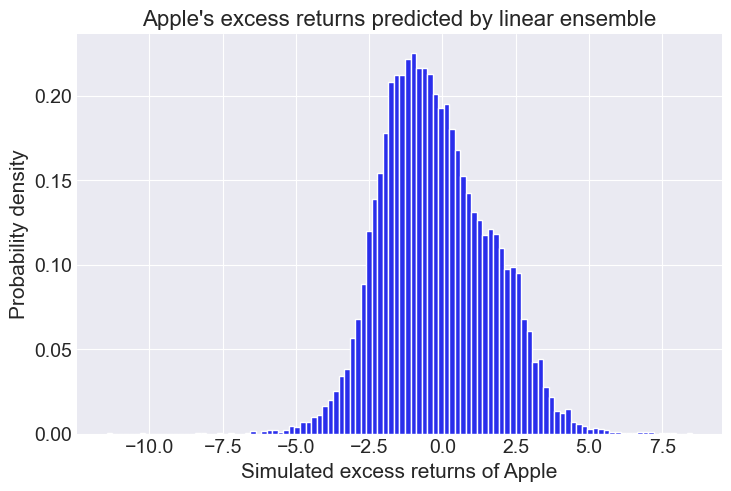

In [31]:
# Flatten posterior predictive xdarray into one numpy array of 
# 20,000 simulated samples.
simulated_data = target_predicted.flatten()

# Create a pandas dataframe to analyze the simulated data.
generated_data = pd.DataFrame(simulated_data, columns=["Values"])

# Print the summary statistics.
print(generated_data.describe().round(2))

# Plot the predicted samples of Apple's excess returns generated by 
# tested linear ensemble.
plt.hist(simulated_data, bins='auto', density=True)
plt.title("Apple's excess returns predicted by linear ensemble")
plt.ylabel('Probability density'), 
plt.xlabel('Simulated excess returns of Apple')

In [32]:
#Market value of position size in the portfolio
position_size = 100000

#The loss function is position size * excess returns of Apple 
#for each prediction. 
losses = simulated_data/100*position_size

#Expected loss is probability weighted arithmetic mean of all the losses 
#and profits
expected_loss = np.mean(losses)

#Range of losses predicted by tested linear ensemble.
print(f"Expected loss on investment of $100,000 is ${expected_loss:.0f}, with max possible loss of ${np.min(losses):.0f} and max possible profit of ${np.max(losses):.0f}")

Expected loss on investment of $100,000 is $-225, with max possible loss of $-11460 and max possible profit of $8525


In [33]:
#Generate a list the 20 worst daily losses predicted 
# by tested linear ensemble.
sorted_returns = generated_data['Values'].sort_values()
sorted_returns.head(20).round(2)

2170    -11.46
14024   -10.27
1154     -8.43
11889    -8.22
234      -7.63
11657    -7.18
14340    -6.68
6774     -6.52
8224     -6.44
8467     -6.43
11151    -6.43
5886     -6.37
6129     -6.10
16537    -6.08
399      -6.07
18317    -6.07
10339    -6.06
600      -6.01
4074     -5.99
15794    -5.98
Name: Values, dtype: float64

In [ ]:
probability = 0.99
gvar = sorted_returns.quantile(1-probability)

print(f"The daily Generative VaR at {probability}% probability is {gvar/100:.2%} implying a dollar loss of ${gvar/100*position_size:.0f} ")

The daily Generative VaR at 0.99% probability is -4.12% implying a dollar loss of $-4124 


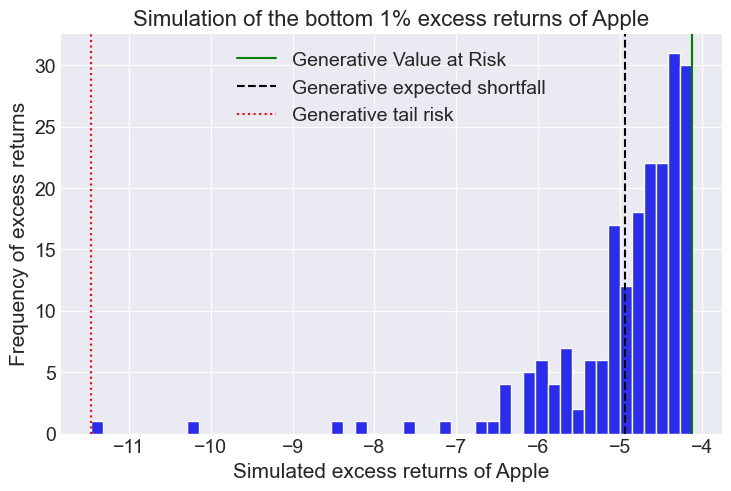

The daily Generative VaR at 0.99% probability is -4.12% implying a dollar loss of $-4124 
The daily Generative expected shortfall at 0.01% probability is -4.95% implying a dollar loss of $-4947
The daily Generative tail risk is -11.46% implying a dollar loss of $-11460


In [ ]:
# Filter the returns that fall below the first percentile
generated_tail = sorted_returns[sorted_returns <= gvar]

# Expected shortfall is the mean of the tail returns.
ges = generated_tail.mean()

# Generated tail risk is the worst possible loss predicted 
# by the linear ensemble
gtr = generated_tail.min()

# Plot a histogram of the worst returns or generated tail risk (GTR)
plt.hist(generated_tail, bins=50)
plt.axvline(x=gvar, color='green', linestyle='solid', 
label='Generative Value at Risk')
plt.axvline(x=ges, color='black', linestyle='dashed', 
label='Generative expected shortfall')
plt.axvline(x=gtr, color='red', linestyle='dotted', 
label='Generative tail risk')

plt.xlabel('Simulated excess returns of Apple')
plt.ylabel('Frequency of excess returns')
plt.title('Simulation of the bottom 1% excess returns of Apple')
plt.legend(loc=0)
plt.show()

print(f"The daily Generative VaR at {probability}% probability is {gvar/100:.2%} implying a dollar loss of ${gvar/100*position_size:.0f} ")
print(f"The daily Generative expected shortfall at {1-probability:.2}% probability is {ges/100:.2%} implying a dollar loss of ${ges/100*position_size:.0f}")
print(f"The daily Generative tail risk is {gtr/100:.2%} implying a dollar loss of ${gtr/100*position_size:.0f}")